# Maxwell-Boltzmann distribution

Plot the Maxwell-Boltzmann distribution

$$ f(v_x) = \left ( \frac{m}{2 \pi kT} \right )^{1/2} e^{-mv_x^2/2kT} $$

Eric Furst  
September 2023

Updated:\
October 2024 to include velocity averages and comparision to kT

As ususal, we import the *numpy* and *matplotlib* libraries. We'll also use the *SciPy* constants library.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

We'll plot the distribution over a range of velocities. By equiparition, the average (mean-squared) velocity is 
$$ \langle v_x^2 \rangle = \frac{kT}{m} $$

When the exponential term is on the order of 
$$ \frac{m v_x^2}{2kT} \sim \mathcal{O}(5) $$
then the exponential function will be close to zero. So, we should choose a range of velocities 
$$ 0 \le v_x \le \left ( \frac{10kT}{m} \right )^{1/2}$$
or so.

In [10]:
# Specify mass (in kg) and temperature (in K)
# This is the mass for nitrogen

m = 14.007/1000/constants.N_A
T = 298
kT = constants.k*T

# Make a range of velocities
vx = np.linspace(0,np.sqrt(10*kT/m),100)

# Calculate the distribution
fvx = np.sqrt(m/2/np.pi/kT)*np.exp(-m*vx**2/2/kT)

Now we can plot the function.

Text(0.5, 1.0, 'Maxwell-Boltzmann Distribution')

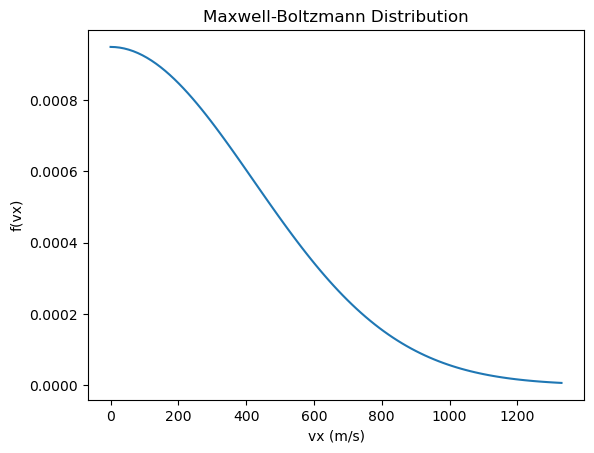

In [11]:
# Plot the data

fig, ax = plt.subplots()
ax.plot(vx, fvx)
plt.xlabel('vx (m/s)')
plt.ylabel('f(vx)')
plt.title('Maxwell-Boltzmann Distribution')

We should plot this at a few different temperatures!

Text(0.5, 1.0, 'Maxwell-Boltzmann Distribution')

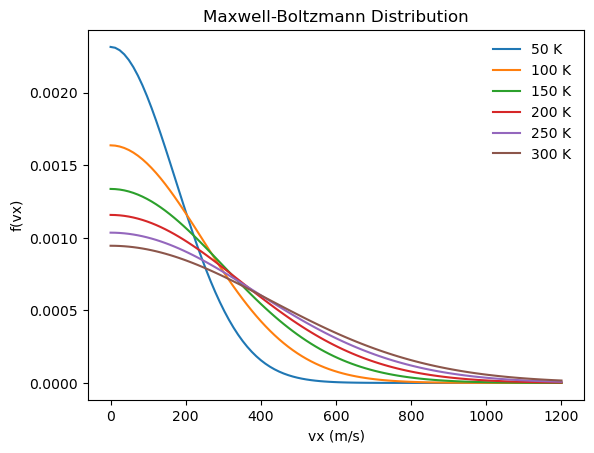

In [12]:
fig, ax = plt.subplots()

for T in range(50, 350, 50) :
    kT = constants.k*T
    vx = np.linspace(0,1200,100)
    fvx = np.sqrt(m/2/np.pi/kT)*np.exp(-m*vx**2/2/kT)
    ax.plot(vx, fvx,label='{} K'.format(T))

plt.legend(frameon=False)
plt.xlabel('vx (m/s)')
plt.ylabel('f(vx)')
plt.title('Maxwell-Boltzmann Distribution')

## Maxwell Distribution of Speed

We can do a similar calcuation for the total velocity, or *speed*. The distribution function is

$$ f(v_x,v_y,v_z) = \left ( \frac{m}{2 \pi kT} \right )^{3/2} e^{-mv^2/2kT} $$

The probability of observing a velocity $v$ is within

$$ f(v)dv = f(v_x, v_y, v_z)dv_xdv_ydv_z $$

which is a volume integral represented by a spherical shell (since $v^2 = v_x^2 + v_y^2 +v_z^2$).

Thus,

$$ f(v)dv = \int_0^{2\pi} \int_0^\pi \left ( \frac{m}{2 \pi kT} \right )^{3/2} e^{-mv^2/2kT} v^2 \sin \theta d\phi d\theta dv $$

$$ f(v) = 4\pi \left ( \frac{m}{2 \pi kT} \right )^{3/2} v^2 e^{-mv^2/2kT} $$

Text(0.5, 1.0, 'Maxwell Distribution of Speeds')

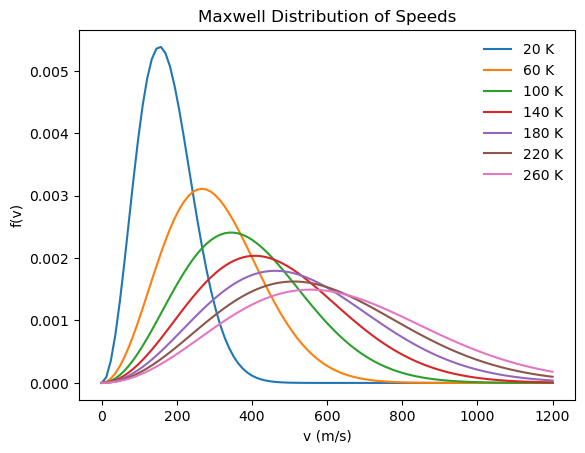

In [13]:
fig, ax = plt.subplots()

for T in range(20, 300, 40) :
    kT = constants.k*T
    v = np.linspace(0,1200,100)

    fvxsq = 4 * np.pi * (np.sqrt(m / (2 * np.pi * kT)))**3 \
        * v**2 * np.exp(-m * v**2 / (2 * kT))

    ax.plot(v, fvxsq, label='{} K'.format(T))

plt.legend(frameon=False)
plt.xlabel('v (m/s)')
plt.ylabel('f(v)')
plt.title('Maxwell Distribution of Speeds')

## What is the average velocity and kinetic energy? 

How does the K.E. compare with kT?

In [14]:
from scipy.integrate import quad

# Define the function fn_fvxsq
# The Maxwell-Boltzmann ditribution
def fn_fvxsq(v, m, kT):
    factor = 4 * np.pi * (np.sqrt(m / (2 * np.pi * kT)))**3
    return factor * v**2 * np.exp(-m * v**2 / (2 * kT))

# Average value function <v>
def average_value_of_fvx(m, kT):
    # Define the limits for integration (0 to infinity)
    lower_limit = 0
    upper_limit = np.inf

    # Numerator: Integral of fvx(v) * v
    numerator_v, _ = quad(lambda v: fn_fvxsq(v, m, kT) * v, lower_limit, upper_limit)

    # Numerator: Integral of fvx(v) * v * v
    numerator_vv, _ = quad(lambda v: fn_fvxsq(v, m, kT) * v * v, lower_limit, upper_limit)

    # Denominator: Integral of fvx(v)
    denominator, _ = quad(lambda v: fn_fvxsq(v, m, kT), lower_limit, upper_limit)

    # Calculate the average value
    average_v = numerator_v / denominator
    average_vv = numerator_vv / denominator

    return average_v, average_vv

m = 14.007/1000/constants.N_A
T = 200
kT = constants.k*T

avg_v, avg_vv = average_value_of_fvx(m, kT)

print(f"At T = {T} K:")
print()
print(f"The average value of v is {avg_v:.0f} m/s")
print(f"m<v>^2/kT = {m*avg_v**2/3/kT:.3f} m/s")
print()
print(f"The average rms v is: {np.sqrt(avg_vv):.0f} m/s")
print(f"m<v^2>/3kT = {m*avg_vv/3/kT:.3f}")


At T = 200 K:

The average value of v is 550 m/s
m<v>^2/kT = 0.849 m/s

The average rms v is: 597 m/s
m<v^2>/3kT = 1.000


Notice that we have to use the mean-squared velocity, not the average velocity, in our calculation. The root mean-squared velocity is about 10% higher than the average velocity.